In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout

In [14]:
df = pd.read_csv('../data/household_power_consumption.csv')
df.head()

,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0


In [15]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)

if 'index' in df.columns:
    df.drop('index', axis=1, inplace=True)

df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month

df.drop(['Date', 'Time', 'datetime'], axis=1, inplace=True)

df = df.apply(pd.to_numeric)

C:\Users\MURALI KARTHIK\AppData\Local\Temp\ipykernel_16296\3071115853.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [16]:
X = df.drop('Global_active_power', axis=1)
y = df['Global_active_power']

In [17]:
print("Feature Columns:")
print(X.columns)

print("\nTotal Features:", len(X.columns))

Feature Columns:
Index(['Global_reactive_power', 'Voltage', 'Global_intensity',
       'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'day',
       'month'],
      dtype='object')

Total Features: 9


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save scaler
pickle.dump(scaler, open('../models/scaler.pkl', 'wb'))

In [19]:
model = Sequential([
    Dense(128, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32)

c:\Users\MURALI KARTHIK\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.0804
Epoch 2/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 36s 6ms/step - loss: 0.0086
Epoch 3/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 0.0058
Epoch 4/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.0051
Epoch 5/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0044
Epoch 6/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - loss: 0.0041
Epoch 7/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - loss: 0.0038
Epoch 8/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 26s 4ms/step - loss: 0.0037
Epoch 9/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - loss: 0.0037
Epoch 10/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - loss: 0.0035
Epoch 11/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 24s 4ms/step - loss: 0.0033
Epoch 12/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.0034
Epoch 13/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - loss: 0.0031
Epoch 14/20
6422/6422 ━━━━━━━━━━━━━━━━━━━━ 29s 4ms/step - loss: 0.0030
Epoch 15/20
642

In [20]:
model.save('../models/model.h5')

In [21]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

1606/1606 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
RMSE: 0.20912080110215026
R2 Score: 0.968219174637709


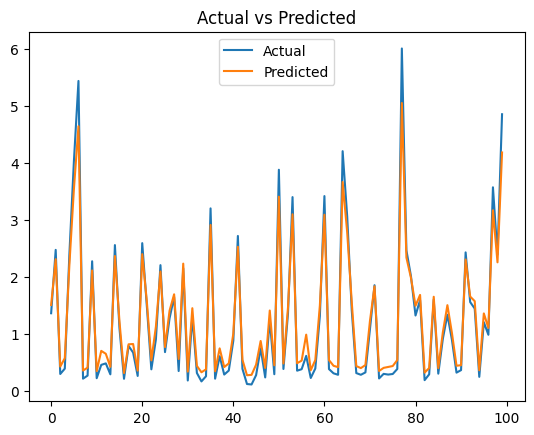

In [22]:
# Save predictions
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})

results.to_csv('../outputs/results.csv', index=False)

# Save graph
plt.figure()
plt.plot(y_test.values[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted")

plt.savefig('../outputs/graphs.png')
plt.show()

In [23]:
from tensorflow.keras.models import load_model

def predict_energy(input_data):
    scaler = pickle.load(open('../models/scaler.pkl', 'rb'))
    
    model = load_model('../models/model.h5', compile=False)

    data = np.array(input_data).reshape(1, -1)
    data = scaler.transform(data)

    pred = model.predict(data)
    return pred[0][0]

In [24]:
sample = X_test[0]
print("Prediction:", predict_energy(sample))

c:\Users\MURALI KARTHIK\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
Prediction: -0.2958768
